In [9]:
import glob
import os

import pandas as pd
import numpy as np

import tifffile as tf
from tifffile import imread
from tifffile import imwrite

import skimage
from skimage.util import compare_images
from skimage import io, color, measure
from skimage.measure import regionprops
from skimage.measure import label as sk_label  # Renaming the label function to avoid conflicts

import matplotlib.pyplot as plt
import matplotlib
import napari

from tqdm import tqdm

%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Import images

images_dir = '/Users/abamford/Documents/iNeurons/automask_model/Retraining/Images'
images_path = os.path.join(images_dir,'*.tif') 
images_files = np.sort(glob.glob(images_path))

# Extract the integers before the first underscore in the filenames
loaded_image_ids = {
    os.path.basename(f).split('_')[0]  # Extract the part before the first underscore
    for f in images_files
}

masks_dir = '/Users/abamford/Documents/iNeurons/automask_model/Retraining/Masks'
masks_path = os.path.join(masks_dir,'*.tif') 
masks_files = np.sort(glob.glob(masks_path))

# Filter the new images based on matching IDs
mask_files = [
    f for f in masks_files
    if os.path.basename(f).split('_')[0] in loaded_image_ids
]

print(len(images_files))
print(len(mask_files))

12
0


In [4]:
# Read images into list

images = []
masks = []

for file in tqdm(images_files):
    image = imread(file)
    images.append(image)

for file in tqdm(mask_files):
    image = imread(file)
    masks.append(image)

100%|██████████| 12/12 [00:00<00:00, 360.48it/s]
0it [00:00, ?it/s]


In [7]:
# Creating emtpy mask images if necessary

masks = [np.zeros((1024, 1024), dtype=np.uint8) for _ in range(len(images_files))]

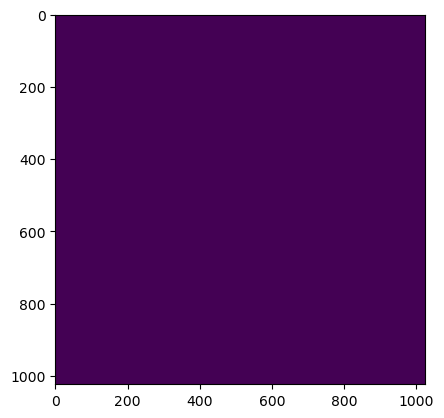

In [8]:
# Create copies of cytoplasm masks for manipulation in Napari

mask_cytoplasm_copy = masks.copy()
plt.imshow(mask_cytoplasm_copy[0])

In [10]:
# Initializes Napari viewer

viewer = napari.Viewer()

Invalid schema for package 'ome-types', please run 'npe2 validate ome-types' to check for manifest errors.


In [11]:
# Adds images to Napari viewer

for i, img in enumerate(images):
    layer_name = f'image_{i}'  # Dynamically name each layer
    viewer.add_image(img, name=layer_name)

In [12]:
# Adds masks to Napari viewer

for i, img in enumerate(mask_cytoplasm_copy):
    layer_name = f'segmentation_{i}'  # Dynamically name each layer
    labels_layer = viewer.add_labels(img, name=layer_name, opacity=0.6)

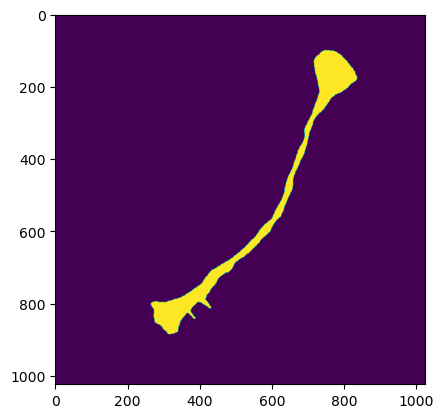

In [15]:
plt.imshow(mask_cytoplasm_copy[4])

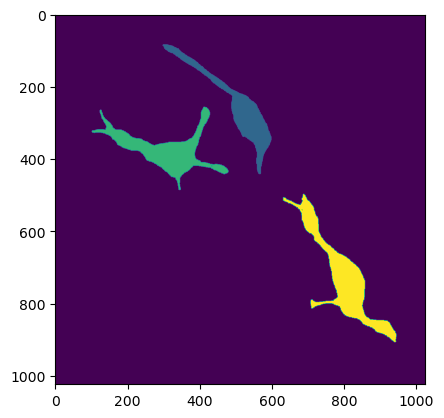

In [23]:
# In case masks need to be converted to label images before saving

from skimage.measure import label

labelled_images = []

for mask in mask_cytoplasm_copy:
    labelled_mask = np.uint16(label(mask))
    labelled_images.append(labelled_mask)

plt.imshow(labelled_images[1])

In [13]:
# Save cytoplasm masks

mask_cytoplasm_dir = r'/Users/abamford/Documents/iNeurons/automask_model/Retraining/Masks'


In [24]:
# Save mask images

# Save mask images
for img, tiff_file in zip(labelled_images, images_files):
    
    # Extract the original file name without the extension
    file_name = os.path.splitext(os.path.basename(tiff_file))[0]
    
    # Replace spaces with underscores
    file_name = file_name.replace(' ', '_')
    
    print(file_name)
    
    # Define the output file path
    output_file = os.path.join(mask_cytoplasm_dir, file_name + '.tif')
    print(output_file)
    
    # Save the manipulated image as a TIFF
    tf.imwrite(output_file, img)

11_17z-0-5_640-30-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo
/Users/abamford/Documents/iNeurons/automask_model/Retraining/Masks/11_17z-0-5_640-30-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo.tif
1_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo
/Users/abamford/Documents/iNeurons/automask_model/Retraining/Masks/1_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo.tif
1_17z-0-5_640-30-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo
/Users/abamford/Documents/iNeurons/automask_model/Retraining/Masks/1_17z-0-5_640-30-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo.tif
2_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo
/Users/abamford/Documents/iNeurons/automask_model/Retraining/Masks/2_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo.tif
3_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo
/Users/abamford/Documents/iNeurons/automask_model/Retraining/Masks/3_17z-0-5_640-20-100ms_500

In [ ]:
mask_files

In [ ]:
len(mask_files)